# Lecture 02: Introduction to deep learning

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §1.1-1.4 (Foundations and function approximation), §1.5-1.9 (Optimization, depth, and regularization), §1.10-1.11 (Generalization, sequence models)  
**Notebook role:** extension  
**Author:** Simon Scheidegger  


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Monitoring training with TensorBoard

TensorBoard is TensorFlow's interactive dashboard for inspecting training
dynamics: scalar metrics (loss, MAE), weight and gradient histograms, the
computational graph, and embeddings.

In this notebook we:
1. Generate a synthetic 2-D regression problem $f(x,y) = \sin(x)\,e^{y}$.
2. Train a small Keras MLP and stream training metrics into a `./logs`
   directory via the `TensorBoard` callback.
3. Save model checkpoints with `ModelCheckpoint`.
4. Inspect the logs both **inline** (with the `%tensorboard` magic) and
   from the **command line** (`tensorboard --logdir=./logs`).

Why care? Out-of-the-box `model.fit` only prints scalar summaries to stdout;
TensorBoard lets you watch losses, parameter histograms, and even embeddings
evolve epoch by epoch. This is essential for debugging deep-learning training
for economic models (Day 2 onward), where loss curves are the primary signal
that the network is converging to a sensible policy.

In [1]:
import os, datetime, shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from sklearn.model_selection import train_test_split

%matplotlib inline

np.random.seed(0)
tf.random.set_seed(0)

print(f'TensorFlow {tf.__version__}')


2026-04-19 19:56:40.566541: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776621400.587139  138204 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776621400.592739  138204 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-19 19:56:40.610413: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.18.0


## 1. Synthetic data
$f(x, y) = \sin(x)\,e^{y}$ on $[-2, 2]^2$.

In [2]:
def generate_data(n):
    x = np.random.uniform(-2, 2, n)
    y = np.random.uniform(-2, 2, n)
    z = np.sin(x) * np.exp(y)
    return np.vstack((x, y)).T.astype(np.float32), z.astype(np.float32)

X, z = generate_data(10_000)
X_tr, X_te, z_tr, z_te = train_test_split(X, z, test_size=0.2, random_state=42)
print(f'Train: {X_tr.shape}, test: {X_te.shape}')


Train: (8000, 2), test: (2000, 2)


## 2. Model and callbacks
Two-hidden-layer ReLU MLP; Adam optimiser; MSE loss.

We attach two callbacks:

- **`ModelCheckpoint`** — saves weights every epoch under `./checkpoints/`.
- **`TensorBoard`** — writes scalar/histogram summaries under `./logs/<timestamp>/`.

In [3]:
model = Sequential([
    Input(shape=(2,)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1),
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


2026-04-19 19:56:43.490802: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Fresh log + checkpoint directories so re-runs do not collide.
ckpt_dir = './checkpoints'
log_dir  = os.path.join('logs', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))
shutil.rmtree(ckpt_dir, ignore_errors=True)
os.makedirs(ckpt_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

ckpt_cb = ModelCheckpoint(
    filepath=os.path.join(ckpt_dir, 'epoch_{epoch:02d}.weights.h5'),
    save_weights_only=True,
    verbose=0,
)
tb_cb = TensorBoard(log_dir=log_dir, histogram_freq=1)

print(f'TensorBoard log dir: {log_dir}')
print(f'Checkpoint dir:    {ckpt_dir}')


TensorBoard log dir: logs/20260419-195643
Checkpoint dir:    ./checkpoints


## 3. Training
50 epochs, batch size 128. The callbacks fire automatically each epoch.

In [5]:
history = model.fit(
    X_tr, z_tr,
    validation_data=(X_te, z_te),
    epochs=50, batch_size=128,
    callbacks=[ckpt_cb, tb_cb],
    verbose=2,
)

test_loss, test_mae = model.evaluate(X_te, z_te, verbose=0)
print(f'\nTest MSE = {test_loss:.4e}, MAE = {test_mae:.4e}')


Epoch 1/50


63/63 - 1s - 22ms/step - loss: 1.3788 - mae: 0.6591 - val_loss: 0.2860 - val_mae: 0.3570


Epoch 2/50


63/63 - 0s - 4ms/step - loss: 0.1612 - mae: 0.2463 - val_loss: 0.1063 - val_mae: 0.2007


Epoch 3/50


...

Epoch 49/50


63/63 - 0s - 4ms/step - loss: 3.3017e-04 - mae: 0.0130 - val_loss: 7.9062e-04 - val_mae: 0.0200


Epoch 50/50


63/63 - 0s - 4ms/step - loss: 3.0907e-04 - mae: 0.0125 - val_loss: 6.3947e-04 - val_mae: 0.0176



Test MSE = 6.3947e-04, MAE = 1.7582e-02


## 4. Inspecting the logs

### 4a. Inline (Jupyter magic)
Inside a notebook you can launch TensorBoard directly with the `%tensorboard`
magic. The cell below loads the extension and embeds the dashboard.

**On Nuvolos** the magic is the recommended path because it serves the
dashboard inside the notebook iframe — no extra port forwarding needed.

In [6]:
# Load the TensorBoard notebook extension and start the dashboard.
# (If %tensorboard is not displayed inline on your platform, use the CLI
# instructions in the next markdown cell.)
%load_ext tensorboard
# Uncomment the next line to launch TensorBoard inline:
# %tensorboard --logdir logs
print('TensorBoard extension loaded. Run %tensorboard --logdir logs to view.')


TensorBoard extension loaded. Run %tensorboard --logdir logs to view.


### 4b. From the command line
From a terminal in the same directory:
```bash
tensorboard --logdir=./logs --port 6006
```
Then open `http://localhost:6006` in a browser. Tabs to look at:

- **Scalars**: `epoch_loss`, `epoch_mae`, plus the validation versions. The two curves should track each other; a wide gap signals over-fitting.
- **Histograms**: distribution of weights and biases per layer, per epoch. Watch for distributions that collapse to zero (dead neurons) or explode.
- **Graphs**: the static computational graph TensorFlow built for the model.

## 5. Sanity-check plots (no TensorBoard required)
Even without the dashboard, the `History` object returned by `fit` contains
the same per-epoch metrics. We use it to plot the loss curve and an
actual-vs-predicted scatter.

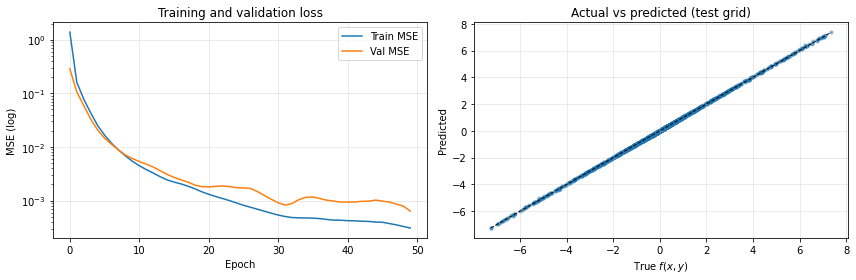

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(history.history['loss'],     label='Train MSE')
axes[0].semilogy(history.history['val_loss'], label='Val MSE')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE (log)')
axes[0].set_title('Training and validation loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

X_new, z_new = generate_data(2000)
z_pred = model.predict(X_new, verbose=0).flatten()
axes[1].scatter(z_new, z_pred, alpha=0.4, s=10)
lo, hi = z_new.min(), z_new.max()
axes[1].plot([lo, hi], [lo, hi], 'k--', lw=1)
axes[1].set_xlabel('True $f(x,y)$')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Actual vs predicted (test grid)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Recap

- Two callbacks are enough to instrument any Keras training loop with
  TensorBoard logging and per-epoch checkpoints.
- The dashboard becomes invaluable in Day 2+ where we train neural networks
  to solve dynamic stochastic models — there, watching the loss components
  (Euler residuals, market clearing) live is the only way to catch a stuck
  training run early.